In [ ]:
Sys.time()

In [ ]:
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(data.table))
suppressPackageStartupMessages(library(repr))
suppressPackageStartupMessages(library(ggrastr))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(cowplot))
suppressPackageStartupMessages(library(ComplexHeatmap))
suppressPackageStartupMessages(library(circlize))
suppressPackageStartupMessages(library(RColorBrewer))
suppressPackageStartupMessages(library(ggplotify))

In [ ]:
projdir <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures'

donors <- c('C29', 'C37', 'C38', 'C39')
donor_order <- donors
donor_hexes <- c('#2851B0', '#C445B8', '#70373D', '#CFCF42')
names(donor_hexes) <- donor_order

tmp_order <- c('Start', 'Sendai', 'Delayed', 'Fail1', 'Inter1', 'Inter2', 'Fail2', 'IPS')
clust_hexes <- c('#C4B921', '#707332', '#9C4F43', '#4F7EB8', '#B07620', '#D698D0', '#0F2061', '#7F5194')
names(clust_hexes) <- tmp_order

base_theme <- theme(
    axis.line = element_blank(),
    panel.border = element_blank(),
    panel.grid = element_blank(),
    panel.background = element_blank(),
    plot.background = element_blank(),
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    legend.position = 'none')

### F: mCG of subcluster-specific ATAC enhancers per branch

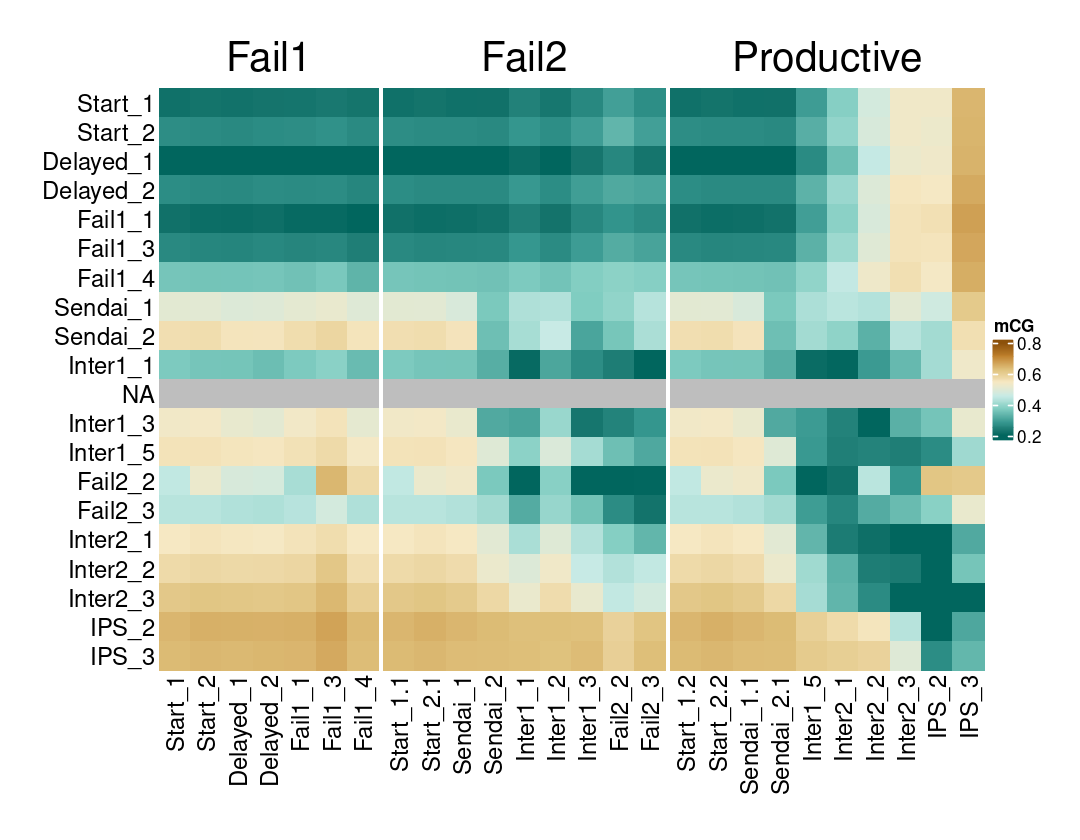

In [ ]:
meth_order <- c('Start_1', 'Start_2',
            'Delayed_1', 'Delayed_2',
            'Fail1_1', 'Fail1_3', 'Fail1_4',
            'Sendai_1', 'Sendai_2',
            'Inter1_1', 'Inter1_2', 'Inter1_3', 'Inter1_5',
            'Fail2_2', 'Fail2_3',
            'Inter2_1', 'Inter2_2', 'Inter2_3',
            'IPS_2', 'IPS_3')

meth_row_order <- c('Start_1', 'Start_2',
            'Delayed_1', 'Delayed_2',
            'Fail1_1', 'Fail1_3', 'Fail1_4',
            'Start_1', 'Start_2',
            'Sendai_1', 'Sendai_2',
            'Inter1_1', 'Inter1_2', 'Inter1_3',
            'Fail2_2', 'Fail2_3',
            'Start_1', 'Start_2',
            'Sendai_1', 'Sendai_2',
            'Inter1_5',
            'Inter2_1', 'Inter2_2', 'Inter2_3',
            'IPS_2', 'IPS_3')

tmp_path <- paste0(projdir, '/csv/figure3/rev_class_chromhmm_peaks_mcg.csv')
peaks_mcg <- as.data.frame(fread(tmp_path))
rownames(peaks_mcg) <- peaks_mcg[,1]
peaks_mcg <- peaks_mcg[,-1]
peaks_mcg <- peaks_mcg[meth_order,meth_row_order]

col_split <- c(rep('Fail1', 7), rep('Fail2', 9), rep('Productive', 10))

w = 9
h = 7
options(repr.plot.width=w, repr.plot.height=h)

col_fun <- colorRamp2(seq(0.2, 0.8, length.out = 8), rev(brewer.pal(8, "BrBG")))

ht <- Heatmap(
    peaks_mcg,
    name = "mCG",
    col = col_fun,
    column_split = col_split,
    row_names_side = "left",
    column_names_side = "bottom",
    cluster_rows = FALSE,
    cluster_columns = FALSE,
    heatmap_width = unit(20, "cm"),
    heatmap_height = unit(16, "cm"),
    row_names_gp = gpar(fontsize = 14),
    column_names_gp = gpar(fontsize = 14),
    column_title_gp = gpar(fontsize = 24),
    column_names_rot = 90,
    column_title = '',
    row_title = '',
)
p <- as.ggplot(ht)
p

### G: Horvath epigenetic age

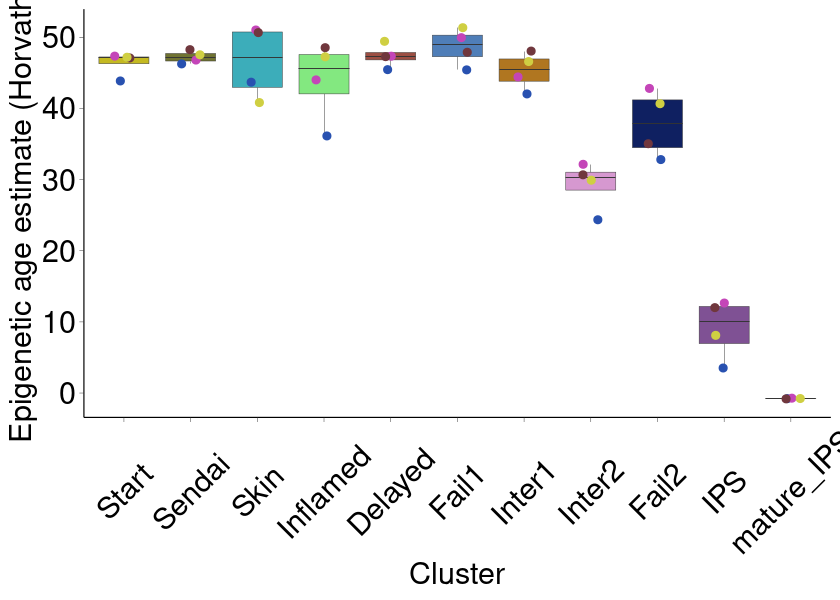

In [ ]:
clust_order <- c('Start', 'Sendai', 'Skin', 'Inflamed', 'Delayed',
               'Fail1', 'Inter1', 'Inter2', 'Fail2', 'IPS', 'mature_IPS')
clust_hexes <- c('#C4B921', '#707332', '#3CADBA', '#83E880', '#9C4F43',
                 '#4F7EB8', '#B07620', '#D698D0', '#0F2061', '#7F5194', '#064023')

tmp_path <- paste0(projdir, '/csv/figure3/top100matches_plot_data.csv')
ct_age <- as.data.frame(fread(tmp_path))
ct_age$cluster <- factor(ct_age$cluster, levels=clust_order)
ct_age$donor <- factor(ct_age$patient, levels=donor_order)

w = 7
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(ct_age, aes(x = cluster, y = horvath_age, fill=cluster)) +
    geom_boxplot(outlier.size = 0.3, outlier.shape = NA, linewidth=0.1) +
    geom_jitter(aes(color = donor), width = 0.15, size = 1.5) +
labs(x = "Cluster", y = "Epigenetic age estimate (Horvath)") +
  theme_bw() +
  base_theme +
   theme(axis.text.x = element_text(size=18, angle=45, hjust=0.5, vjust=0.5, color='black'),
        axis.text.y = element_text(size=18, color='black'),
        axis.title.x = element_text(size=18, color='black'),
        axis.title.y = element_text(size=18, color='black'),
        axis.line = element_line(linewidth=0.25, color='black'),
         axis.ticks.x = element_line(linewidth=0.1),
         axis.ticks.y = element_line(linewidth=0.1),
         legend.position = 'none',
        plot.title = element_text(size = 20, hjust = 0.2)) +
    scale_fill_manual(values = clust_hexes) +
    scale_color_manual(values = donor_hexes)

### H: Start / Delayed / Fail1 in four modalities

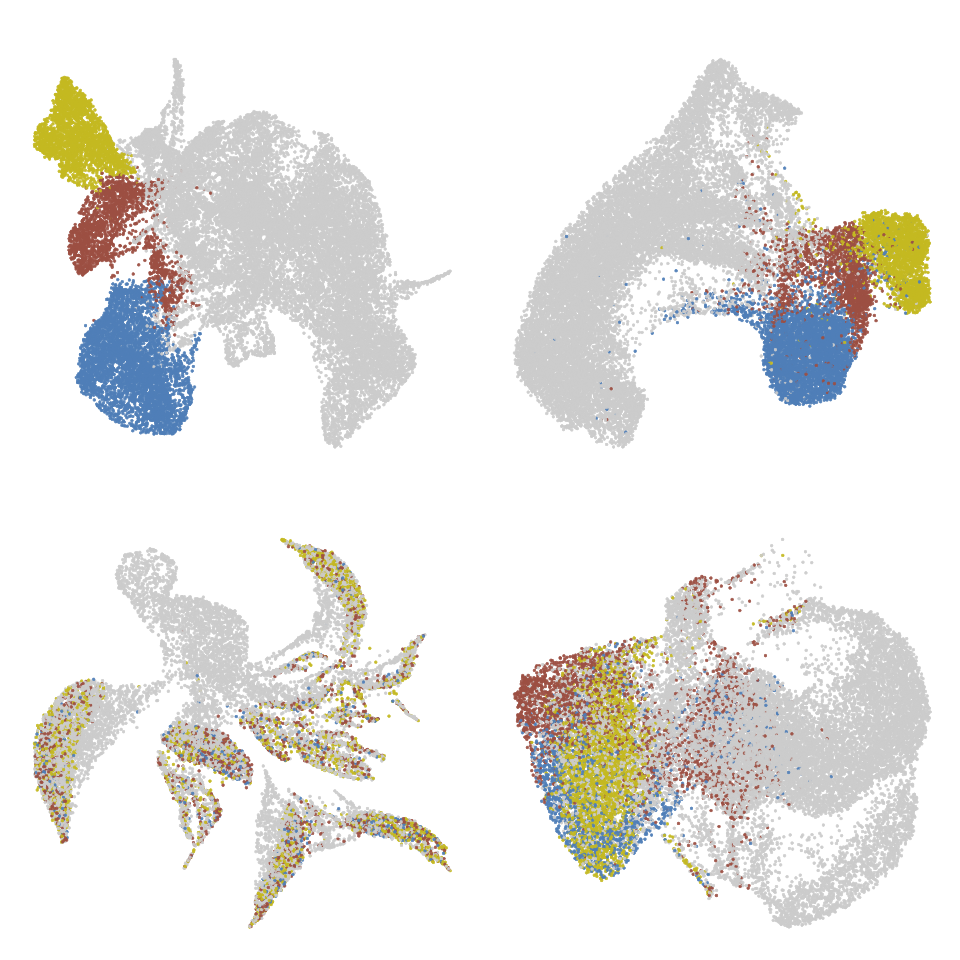

In [ ]:
highlight_hexes <- c("Start" ='#C4B921',  "Delayed" = '#9C4F43', "Fail1" = '#4F7EB8', "Other" = "grey80")
highlight_order <- c("Start", "Delayed", "Fail1", "Other")
groups_to_highlight <- c("Start", "Delayed", "Fail1")

rna_path = paste0(projdir, '/csv/figure1/rna_umap_meta.csv')
rna_umap = as.data.frame(fread(rna_path, sep='\t'))
rna_umap$coarse <- factor(rna_umap$coarse, levels=tmp_order)
rna_umap <- rna_umap %>%
    mutate(
        coarse_chr = as.character(coarse),
        highlight = ifelse(coarse_chr %in% groups_to_highlight, coarse_chr, "Other")
    )
rna_umap$highlight <- factor(rna_umap$highlight, levels=highlight_order)

atac_path = paste0(projdir, '/csv/figure3/atac_umap_meta.csv')
atac_umap = as.data.frame(fread(atac_path, sep='\t'))
atac_umap$coarse <- factor(atac_umap$coarse, levels=tmp_order)
atac_umap <- atac_umap %>%
    mutate(
        coarse_chr = as.character(coarse),
        highlight = ifelse(coarse_chr %in% groups_to_highlight, coarse_chr, "Other")
    )
atac_umap$highlight <- factor(atac_umap$highlight, levels=highlight_order)

mcg_path = paste0(projdir, '/csv/figure3/snmct_mcg_umap.csv')
mcg_umap = as.data.frame(fread(mcg_path, sep='\t'))
mcg_umap$cluster <- factor(mcg_umap$cluster, levels=tmp_order)
mcg_umap <- mcg_umap %>%
    mutate(
        cluster_chr = as.character(cluster),
        highlight = ifelse(cluster_chr %in% groups_to_highlight, cluster_chr, "Other")
    )
mcg_umap$highlight <- factor(mcg_umap$highlight, levels=highlight_order)

hic_path = paste0(projdir, '/csv/figure3/snm3c_umap_meta.csv')
hic_umap = as.data.frame(fread(hic_path, sep='\t'))
hic_umap$coarse <- factor(hic_umap$coarse, levels=tmp_order)
hic_umap <- hic_umap %>%
    mutate(
        coarse_chr = as.character(coarse),
        highlight = ifelse(coarse_chr %in% groups_to_highlight, coarse_chr, "Other")
    )
hic_umap$highlight <- factor(hic_umap$highlight, levels=highlight_order)

plot_umap <- function(tmp_umap) {
    set.seed(1)
    shuffled_tmp_umap <- tmp_umap[sample(nrow(tmp_umap)), ]

    ggplot(shuffled_tmp_umap, aes(x = umap0, y = umap1, color = highlight)) +
        geom_point_rast(alpha=0.8, size=0.1) +
      labs(x = "", y = "", title = '') +
      theme_bw() +
       base_theme +
       theme(axis.text = element_blank(),
            axis.title = element_blank(),
            axis.line = element_blank(),
             legend.position = 'none') +
            scale_color_manual(values = highlight_hexes)
}

umap_list <- list(rna_umap, atac_umap, mcg_umap, hic_umap)
plot_list <- list()

for (i in seq_along(umap_list)) {
    tmp_umap = umap_list[[i]]
    plot_list[[i]] = plot_umap(tmp_umap)
}

w = 8
h = 8
options(repr.plot.width=w, repr.plot.height=h)
combined_plot <- plot_grid(plotlist = plot_list, ncol=2)
combined_plot

### I: Start/Delayed DMRs and their reversion in Fail1

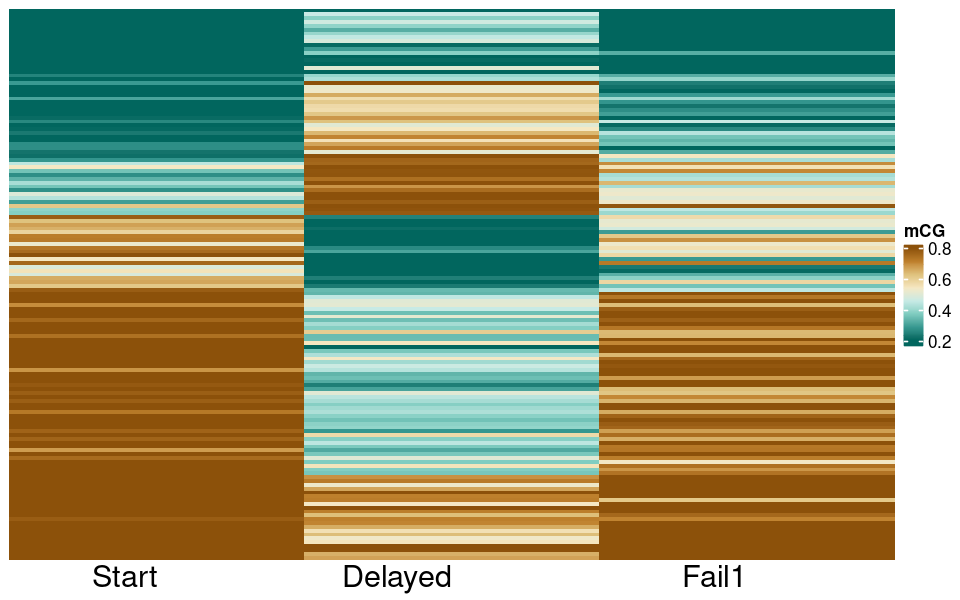

In [ ]:
tmp_path = paste0(projdir, '/csv/figure4/fail1_traj_reversal_dmrs.csv')
fail1_reversal = as.data.frame(fread(tmp_path, sep='\t'))
fail1_reversal <- fail1_reversal[,-1]

p <- Heatmap(
    fail1_reversal,
    name = "mCG",
    col = col_fun <- colorRamp2(seq(0.2, 0.8, length.out = 8), rev(brewer.pal(8, "BrBG"))),
    row_names_side = "left",
    column_names_side = "bottom",
    show_row_names = FALSE,
    show_column_names = TRUE,
    cluster_rows = FALSE,
    cluster_columns = FALSE,
    row_names_gp = gpar(fontsize = 12),
    column_names_gp = gpar(fontsize = 18),
    column_title_gp = gpar(fontsize = 18),
    column_names_rot = 0,
    row_title_rot = 90,
    column_title = '',
    )

p <- as.ggplot(p) +
        base_theme

w = 8
h = 5
options(repr.plot.width = w, repr.plot.height = h)
p

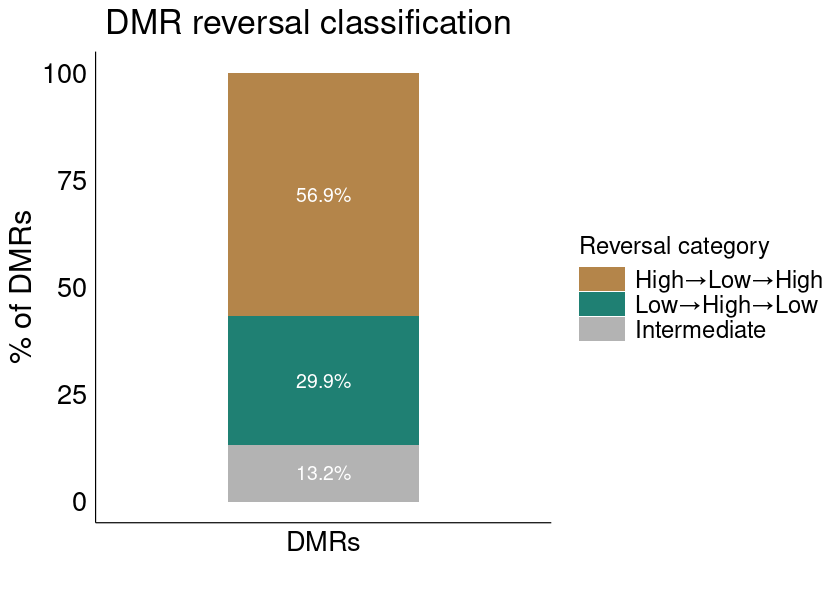

In [ ]:
tmp_path = paste0(projdir, '/csv/figure4/fail1_traj_reversal_dmrs.csv')
df = as.data.frame(fread(tmp_path, sep='\t'))
df <- df[,-1]
df <- df %>%
  mutate(
    delta_sd = Delayed - Start,
    delta_df1 = Fail1 - Delayed,

    category = case_when(
      delta_sd <= -0.1 & delta_df1 >=  0.1 ~ "High→Low→High",
      delta_sd >=  0.1 & delta_df1 <= -0.1 ~ "Low→High→Low",
      TRUE ~ "Intermediate"
    )
  )

category_summary <- df %>%
  count(category) %>%
  mutate(pct = n / sum(n) * 100)

pct_reversed <- category_summary %>%
  filter(category != "Intermediate") %>%
  summarise(total_pct = sum(pct)) %>%
  pull(total_pct)

category_summary <- category_summary %>%
  mutate(category = factor(category, levels = c("High→Low→High", "Low→High→Low", "Intermediate")))

p <- ggplot(category_summary, aes(x = "DMRs", y = pct, fill = category)) +
  geom_bar(stat = "identity", position = "stack", width = 0.5) +
  geom_text(aes(label = paste0(round(pct, 1), "%")),
            position = position_stack(vjust = 0.5), size = 4, color = "white") +
  scale_fill_manual(values = c("High→Low→High" = "#B4854A",
                                 "Low→High→Low" = "#1F8073",
                                 "Intermediate" = "grey70")) +
  labs(x = "", y = "% of DMRs", fill = "Reversal category", title = "DMR reversal classification") +
  theme_bw() +
  base_theme +
   theme(axis.text.x = element_text(size=16, color='black'),
        axis.text.y = element_text(size=16, color='black'),
        axis.title.x = element_text(size=18, color='black'),
        axis.title.y = element_text(size=18, color='black'),
        axis.line = element_line(linewidth=0.25, color='black'),
         panel.border = element_blank(),
         panel.grid = element_blank(),
         panel.background = element_blank(),
         plot.background  = element_blank(),
         legend.position = 'right',
         legend.key.size = unit(1, "cm"),
         legend.text = element_text(size = 14),
         legend.title = element_text(size=14),
         legend.key.height = unit(0.5, 'cm'),
        plot.title = element_text(size = 20, hjust = 0.2))

w = 7
h = 5
options(repr.plot.width = w, repr.plot.height = h)
p

In [ ]:
sessionInfo()

In [ ]:
Sys.time()